In [ ]:
import pandas as pd
import numpy as num
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
sns.set_style('whitegrid')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/COLLEGE/SEM 3/EDA/ncr_rides_final_event_dataset_2024.csv')
df.head()

,datetime,Date,Time,year,month,day,weekday,hour,ride_date,Event,...,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23 12:29:38,2024-03-23,12:29:38,2024,3,23,Saturday,12,2024-03-23,Normal Day,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29 18:01:39,2024-11-29,18:01:39,2024,11,29,Friday,18,2024-11-29,Wedding_Season,...,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,NaN,NaN,UPI
2,2024-08-23 08:56:10,2024-08-23,08:56:10,2024,8,23,Friday,8,2024-08-23,Monsoon,...,25.8,NaN,NaN,NaN,NaN,NaN,NaN,4.9,4.9,Debit Card
3,2024-10-21 17:17:25,2024-10-21,17:17:25,2024,10,21,Monday,17,2024-10-21,Normal Day,...,28.5,NaN,NaN,NaN,NaN,NaN,NaN,4.6,5.0,UPI
4,2024-09-16 22:08:00,2024-09-16,22:08:00,2024,9,16,Monday,22,2024-09-16,Normal Day,...,19.6,NaN,NaN,NaN,NaN,NaN,NaN,4.1,4.3,UPI


In [ ]:
df.tail()

,datetime,Date,Time,year,month,day,weekday,hour,ride_date,Event,...,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Driver Ratings,Customer Rating,Payment Method
160604,2024-11-24 15:55:09,2024-11-24,15:55:09,2024,11,24,Sunday,15,2024-11-24,Wedding_Season,...,30.8,NaN,NaN,NaN,NaN,NaN,NaN,4.8,5.0,UPI
160605,2024-09-18 10:55:15,2024-09-18,10:55:15,2024,9,18,Wednesday,10,2024-09-18,Normal Day,...,23.4,NaN,NaN,NaN,NaN,NaN,NaN,3.9,4.4,Cash
160606,2024-10-05 07:53:34,2024-10-05,07:53:34,2024,10,5,Saturday,7,2024-10-05,Navratri,...,39.6,NaN,NaN,NaN,NaN,NaN,NaN,4.1,3.7,UPI
160607,2024-10-05 07:53:34,2024-10-05,07:53:34,2024,10,5,Saturday,7,2024-10-05,Festive_Sales,...,39.6,NaN,NaN,NaN,NaN,NaN,NaN,4.1,3.7,UPI
160608,2024-03-10 15:38:03,2024-03-10,15:38:03,2024,3,10,Sunday,15,2024-03-10,Wedding_Season,...,33.7,NaN,NaN,NaN,NaN,NaN,NaN,4.6,4.9,Credit Card


In [ ]:
# Check the shape of the DataFrame df
print("Number of Rows",df.shape[0])
print("Number of Columns",df.shape[1])

Number of Rows 160609
Number of Columns 29


In [ ]:
# Print the column names of the DataFrame df
print("Columns Names : ", df.columns)

Columns Names :  Index(['datetime', 'Date', 'Time', 'year', 'month', 'day', 'weekday', 'hour',
       'ride_date', 'Event', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Ride Distance',
       'Booking Value', 'Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Driver Ratings', 'Customer Rating',
       'Payment Method'],
      dtype='object')


In [ ]:
df.isnull().sum()

,0
datetime,0
Date,0
Time,0
year,0
month,0
day,0
weekday,0
hour,0
ride_date,0
Event,0


In [ ]:
# Clean ID columns (remove stray quote characters)
df['Booking ID'] = df['Booking ID'].str.strip('"')
df['Customer ID'] = df['Customer ID'].str.strip('"')

In [ ]:
# Parse datetime properly
df['datetime'] = pd.to_datetime(df['datetime'])

In [ ]:
print(df.shape)
df.info()

(160609, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160609 entries, 0 to 160608
Data columns (total 29 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   datetime                           160609 non-null  datetime64[ns]
 1   Date                               160609 non-null  object        
 2   Time                               160609 non-null  object        
 3   year                               160609 non-null  int64         
 4   month                              160609 non-null  int64         
 5   day                                160609 non-null  int64         
 6   weekday                            160609 non-null  object        
 7   hour                               160609 non-null  int64         
 8   ride_date                          160609 non-null  object        
 9   Event                              160609 non-null  object        
 10  Booking

Cell 2 — Handle Missing Values (structural, not random)

In [ ]:
# Flag columns: NaN means "did not happen" -> fill with 0
flag_cols = ['Cancelled Rides by Customer', 'Cancelled Rides by Driver', 'Incomplete Rides']
df[flag_cols] = df[flag_cols].fillna(0)

In [ ]:
# Reason columns: NaN means "not applicable"
reason_cols = ['Reason for cancelling by Customer', 'Driver Cancellation Reason', 'Incomplete Rides Reason']
df[reason_cols] = df[reason_cols].fillna('Not Applicable')

In [ ]:
# Trip-detail columns (Ride Distance, Booking Value, Avg VTAT, Avg CTAT, Payment Method):
# leave as NaN -- these genuinely don't exist for rides that never started.
# Just confirm the logic holds:
no_trip_mask = df['Booking Status'].isin(['Cancelled by Customer', 'Cancelled by Driver', 'No Driver Found'])
print("Rides with no trip started:", no_trip_mask.sum())
print("Ride Distance NaN count:", df['Ride Distance'].isna().sum())  # should roughly match

Rides with no trip started: 51280
Ride Distance NaN count: 51280


In [ ]:
# Sanity check after cleaning
df.isnull().sum()

,0
datetime,0
Date,0
Time,0
year,0
month,0
day,0
weekday,0
hour,0
ride_date,0
Event,0


Cell 3 — Feature Engineering

In [ ]:
df['is_weekend'] = df['weekday'].isin(['Saturday', 'Sunday']).astype(int)

def time_of_day(h):
    if 5 <= h < 12: return 'Morning'
    elif 12 <= h < 17: return 'Afternoon'
    elif 17 <= h < 21: return 'Evening'
    else: return 'Night'

In [ ]:
df['time_of_day'] = df['hour'].apply(time_of_day)

In [ ]:
# Peak hours (typical commute peaks — adjust after you look at hourly volume in Cell 5)
df['is_peak_hour'] = df['hour'].isin([8, 9, 10, 17, 18, 19, 20]).astype(int)

In [ ]:
# Simplify Booking Status into a binary outcome for later analysis
df['is_completed'] = (df['Booking Status'] == 'Completed').astype(int)

In [ ]:
df[['datetime', 'hour', 'time_of_day', 'is_weekend', 'is_peak_hour', 'is_completed']].head()

,datetime,hour,time_of_day,is_weekend,is_peak_hour,is_completed
0,2024-03-23 12:29:38,12,Afternoon,1,0,0
1,2024-11-29 18:01:39,18,Evening,0,1,0
2,2024-08-23 08:56:10,8,Morning,0,1,1
3,2024-10-21 17:17:25,17,Evening,0,1,1
4,2024-09-16 22:08:00,22,Night,0,0,1


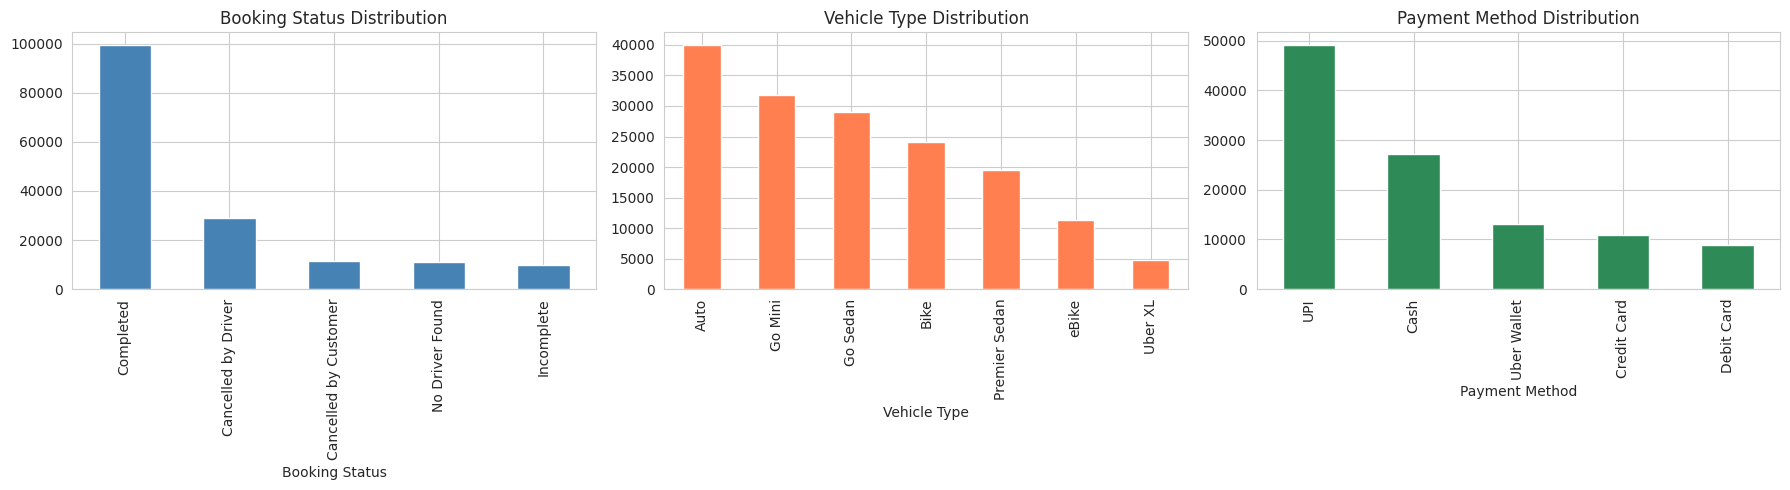

In [ ]:
sns.set_style('whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['Booking Status'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Booking Status Distribution')

df['Vehicle Type'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Vehicle Type Distribution')

df['Payment Method'].value_counts().plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Payment Method Distribution')

plt.tight_layout()
plt.show()

Cell 5 — Univariate: Numeric Distributions

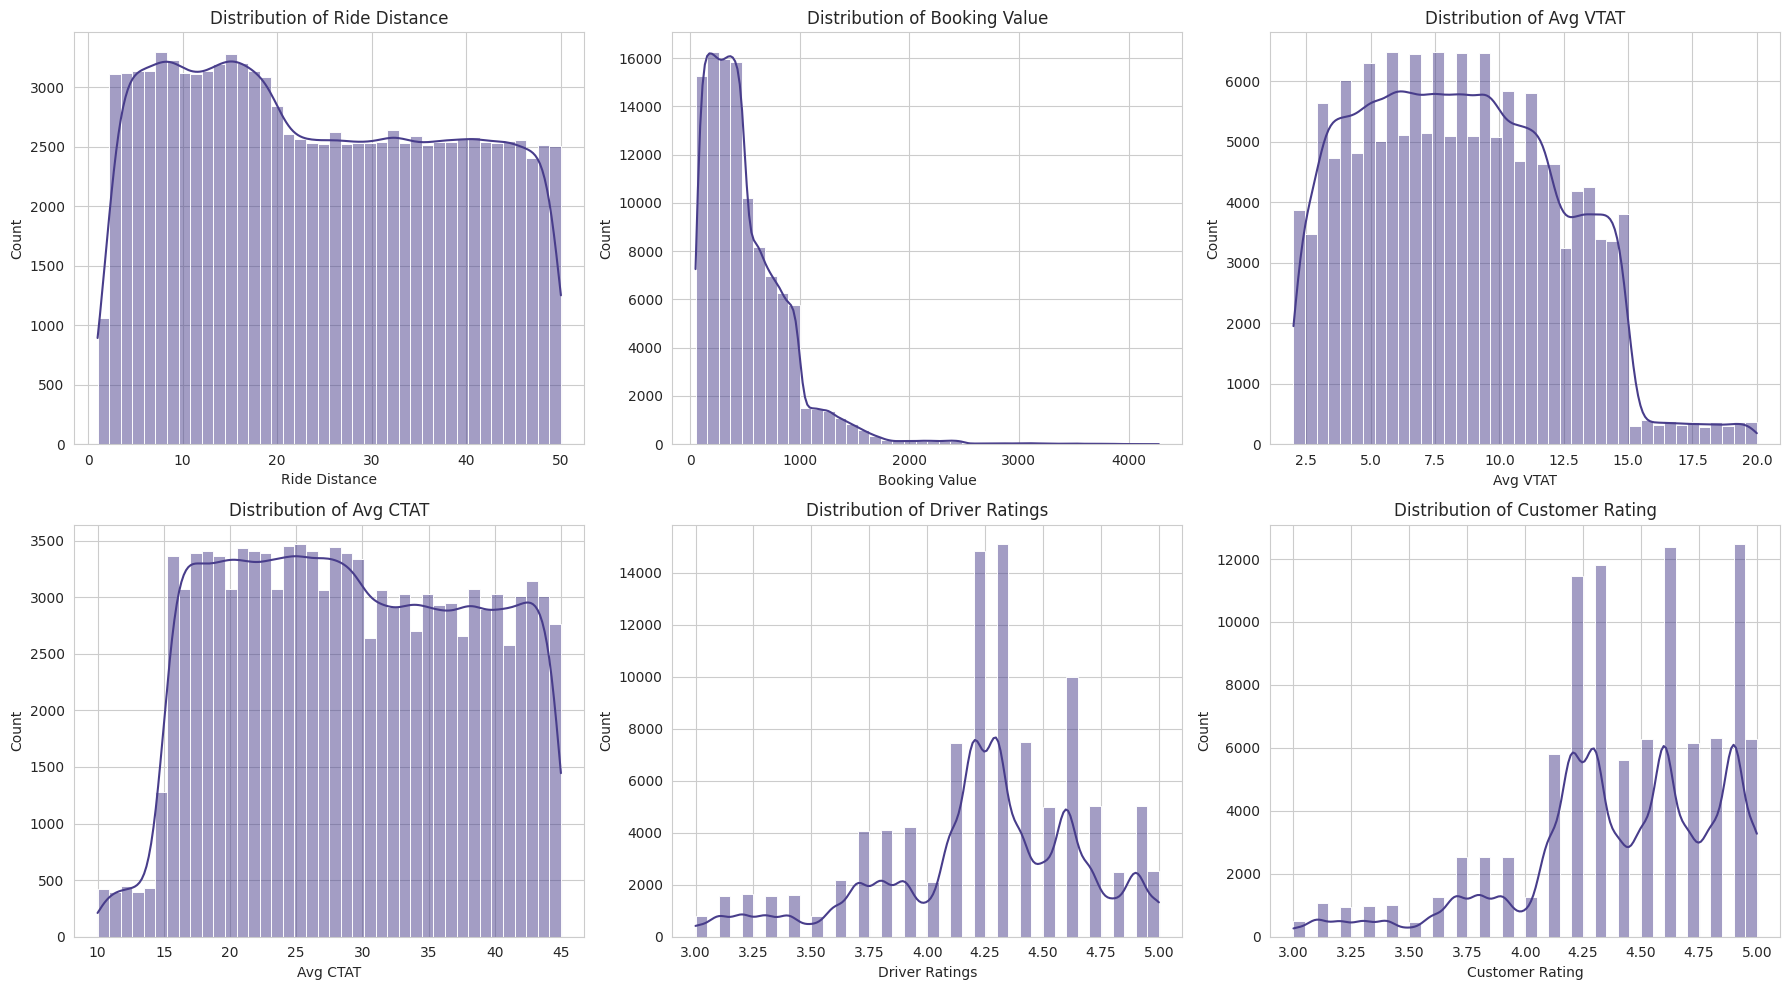

In [ ]:
numeric_cols = ['Ride Distance', 'Booking Value', 'Avg VTAT', 'Avg CTAT', 'Driver Ratings', 'Customer Rating']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), bins=40, kde=True, ax=axes[i], color='darkslateblue')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()


In [ ]:
# Quick outlier check
df[numeric_cols].describe()

,Ride Distance,Booking Value,Avg VTAT,Avg CTAT,Driver Ratings,Customer Rating
count,109329.000000,109329.000000,149402.000000,109329.000000,99666.000000,99666.000000
mean,24.616326,508.638495,8.452117,29.137421,4.230682,4.404499
std,13.999738,396.312667,3.772035,8.907190,0.436971,0.437776
min,1.000000,50.000000,2.000000,10.000000,3.000000,3.000000
25%,12.430000,234.000000,5.300000,21.600000,4.100000,4.200000
50%,23.670000,414.000000,8.300000,28.700000,4.300000,4.500000
75%,36.790000,689.000000,11.300000,36.800000,4.600000,4.800000
max,50.000000,4277.000000,20.000000,45.000000,5.000000,5.000000


Cell 6 — Hourly & Weekday Ride Volume

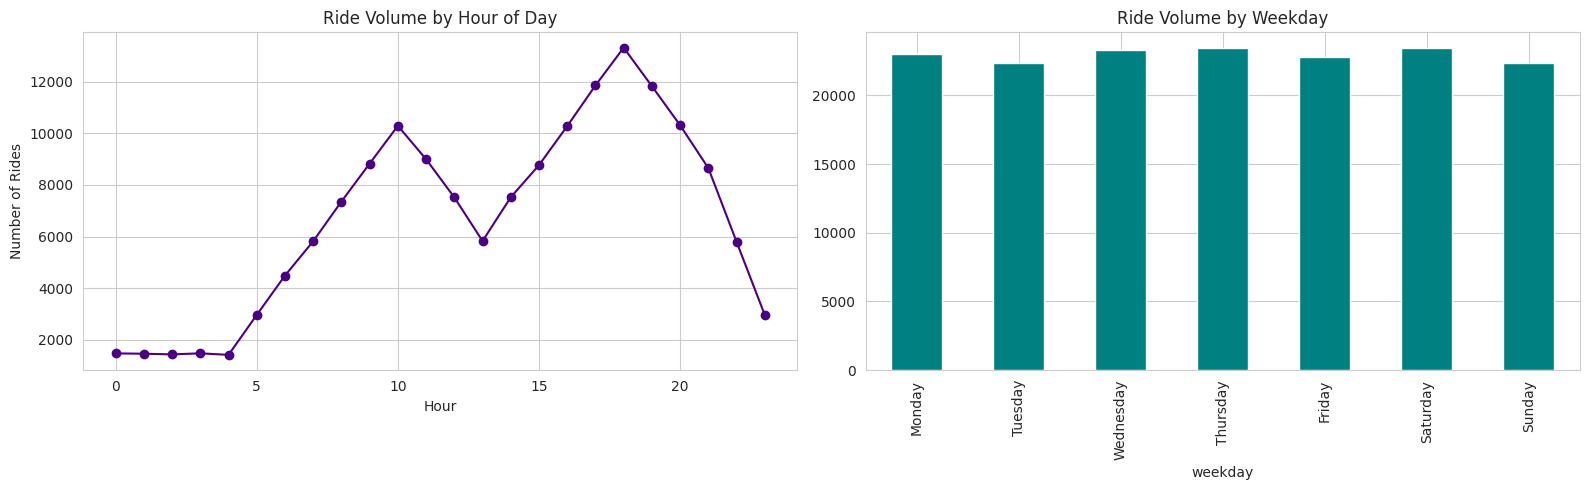

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df.groupby('hour').size().plot(kind='line', marker='o', ax=axes[0], color='indigo')
axes[0].set_title('Ride Volume by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Number of Rides')

weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df.groupby('weekday').size().reindex(weekday_order).plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Ride Volume by Weekday')

plt.tight_layout()
plt.show()

Cell 7 — Completion Rate by Hour & Weekday (Phase 3)

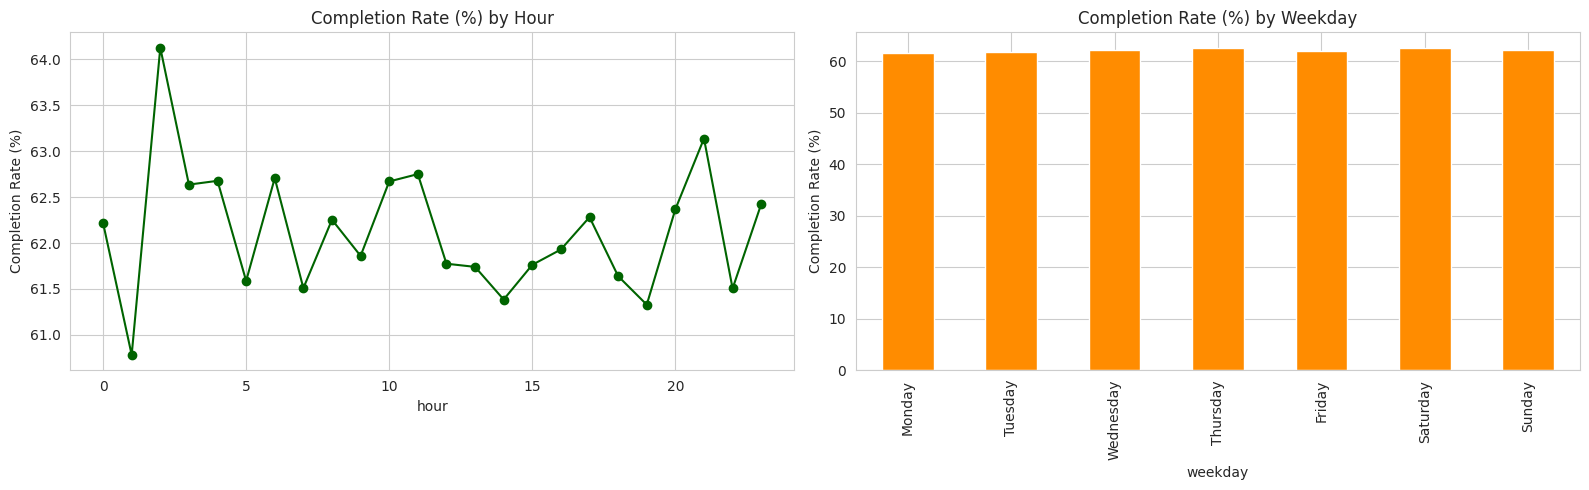

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hourly_completion = df.groupby('hour')['is_completed'].mean() * 100
hourly_completion.plot(kind='line', marker='o', ax=axes[0], color='darkgreen')
axes[0].set_title('Completion Rate (%) by Hour')
axes[0].set_ylabel('Completion Rate (%)')

weekday_completion = df.groupby('weekday')['is_completed'].mean().reindex(weekday_order) * 100
weekday_completion.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Completion Rate (%) by Weekday')
axes[1].set_ylabel('Completion Rate (%)')

plt.tight_layout()
plt.show()

Cell 8 — Monthly Trend + Festival/Event Overlay

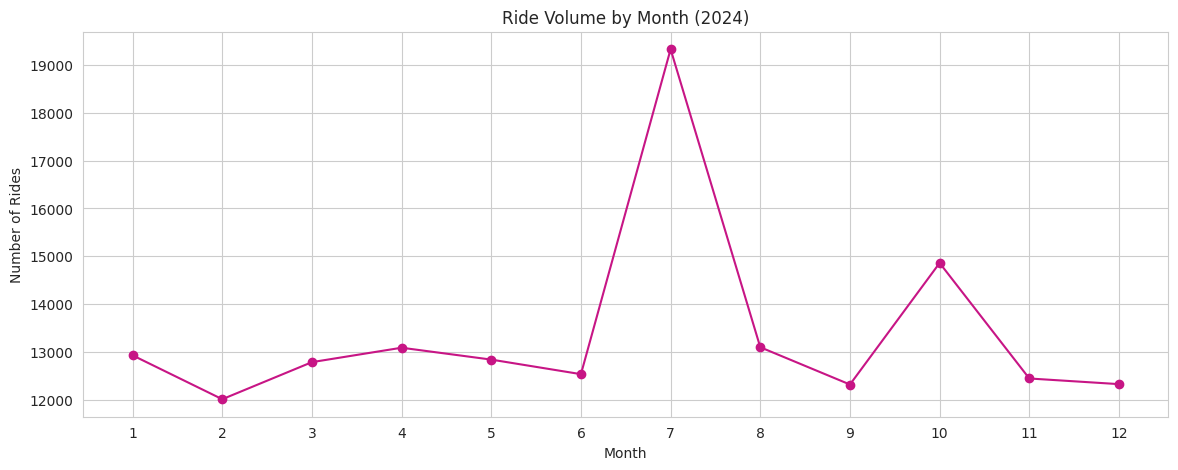

In [ ]:
monthly_volume = df.groupby('month').size()

plt.figure(figsize=(14, 5))
monthly_volume.plot(kind='line', marker='o', color='mediumvioletred')
plt.title('Ride Volume by Month (2024)')
plt.xlabel('Month')
plt.ylabel('Number of Rides')
plt.xticks(range(1,13))
plt.show()

In [ ]:
# Event category volumes
event_summary = df.groupby('Event').agg(
    ride_count=('Booking ID', 'count'),
    completion_rate=('is_completed', 'mean'),
    avg_booking_value=('Booking Value', 'mean')
).sort_values('ride_count', ascending=False)

event_summary['completion_rate'] = (event_summary['completion_rate'] * 100).round(2)
event_summary

,ride_count,completion_rate,avg_booking_value
Event,,,
Normal Day,73084,62.14,505.532542
Wedding_Season,33173,62.06,510.570713
Monsoon,31838,61.44,501.910724
Navratri,6673,62.52,525.677925
Monsoon_Sales,6318,62.41,508.861028
Diwali,2466,63.10,568.896270
Festive_Sales,2058,62.73,491.778405
Eid-ul-Adha,834,64.03,562.860870
Eid-ul-Fitr,833,63.27,443.424825


Cell 9 — Event Impact Visualization

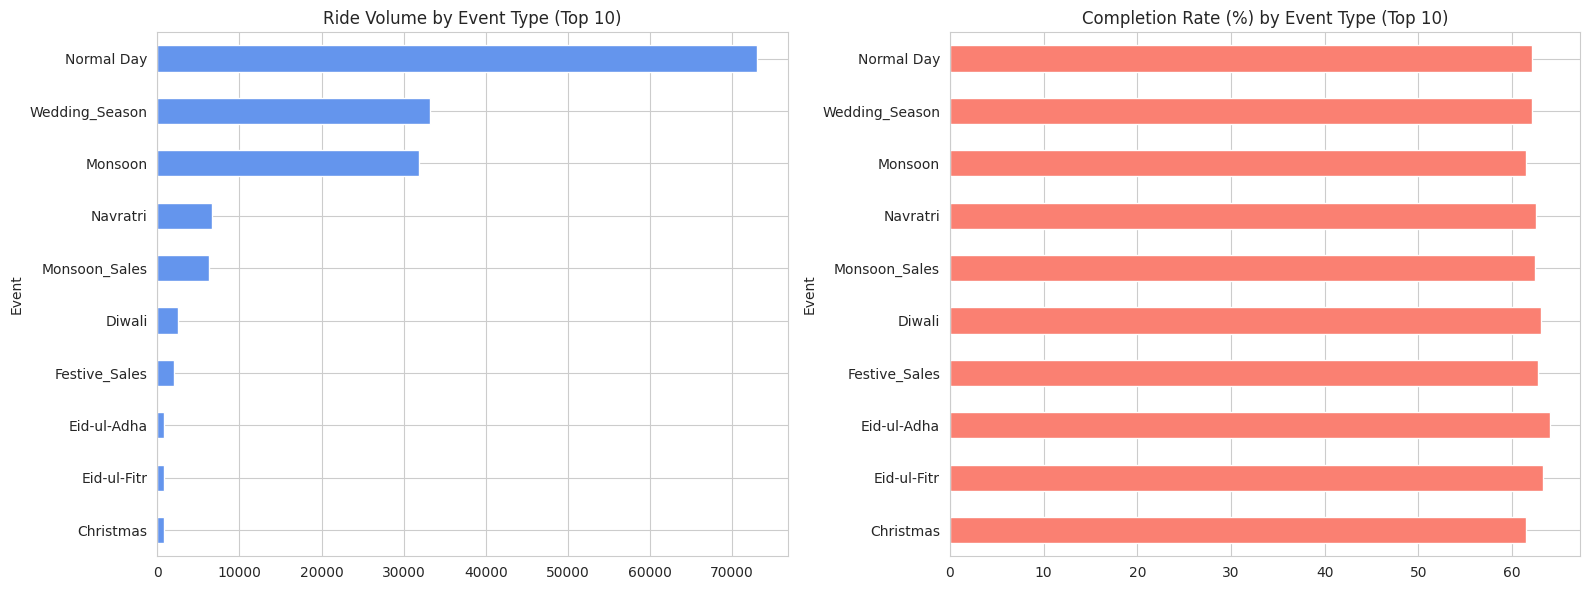

In [ ]:
top_events = event_summary.head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_events['ride_count'].plot(kind='barh', ax=axes[0], color='cornflowerblue')
axes[0].set_title('Ride Volume by Event Type (Top 10)')
axes[0].invert_yaxis()

top_events['completion_rate'].plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('Completion Rate (%) by Event Type (Top 10)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

Cell 10 — Cancellation Analysis by Vehicle Type (Phase 4)

In [ ]:
cancel_by_vehicle = df.groupby('Vehicle Type').agg(
    total_rides=('Booking ID', 'count'),
    cancelled_by_customer=('Cancelled Rides by Customer', 'sum'),
    cancelled_by_driver=('Cancelled Rides by Driver', 'sum'),
    incomplete=('Incomplete Rides', 'sum')
)
cancel_by_vehicle['customer_cancel_rate'] = (cancel_by_vehicle['cancelled_by_customer'] / cancel_by_vehicle['total_rides'] * 100).round(2)
cancel_by_vehicle['driver_cancel_rate'] = (cancel_by_vehicle['cancelled_by_driver'] / cancel_by_vehicle['total_rides'] * 100).round(2)

cancel_by_vehicle.sort_values('driver_cancel_rate', ascending=False)

,total_rides,cancelled_by_customer,cancelled_by_driver,incomplete,customer_cancel_rate,driver_cancel_rate
Vehicle Type,,,,,,
Go Sedan,29042,1948.0,5346.0,1762.0,6.71,18.41
eBike,11285,772.0,2049.0,669.0,6.84,18.16
Bike,24108,1695.0,4349.0,1417.0,7.03,18.04
Premier Sedan,19453,1375.0,3489.0,1146.0,7.07,17.94
Go Mini,31873,2243.0,5666.0,1952.0,7.04,17.78
Auto,40066,2866.0,7110.0,2428.0,7.15,17.75
Uber XL,4782,355.0,810.0,289.0,7.42,16.94


Cell 11 — Top Cancellation Reasons

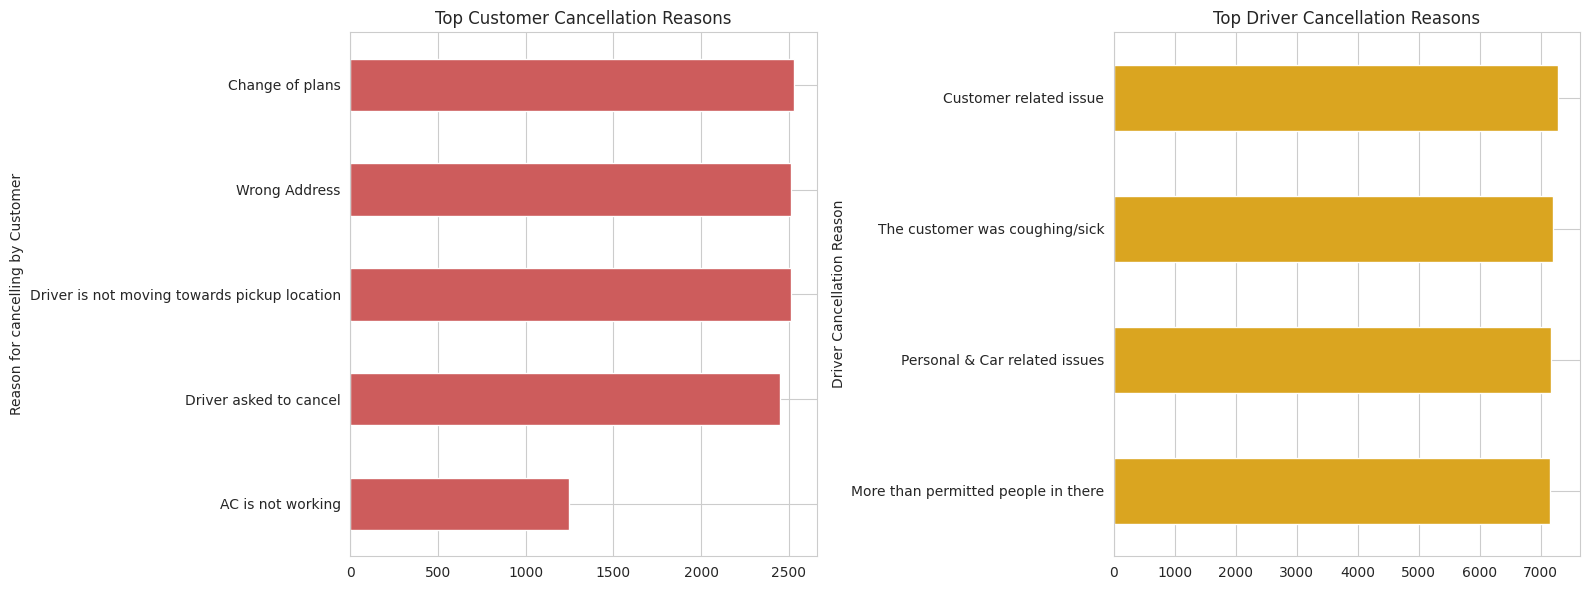

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

customer_reasons = df[df['Reason for cancelling by Customer'] != 'Not Applicable']['Reason for cancelling by Customer'].value_counts()
customer_reasons.plot(kind='barh', ax=axes[0], color='indianred')
axes[0].set_title('Top Customer Cancellation Reasons')
axes[0].invert_yaxis()

driver_reasons = df[df['Driver Cancellation Reason'] != 'Not Applicable']['Driver Cancellation Reason'].value_counts()
driver_reasons.plot(kind='barh', ax=axes[1], color='goldenrod')
axes[1].set_title('Top Driver Cancellation Reasons')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

Cell 12 — VTAT (Wait Time) vs Cancellation Hypothesis

Booking Status
Cancelled by Customer    12.501591
Completed                 8.505739
Cancelled by Driver       7.502238
Incomplete                6.015761
No Driver Found                NaN
Name: Avg VTAT, dtype: float64


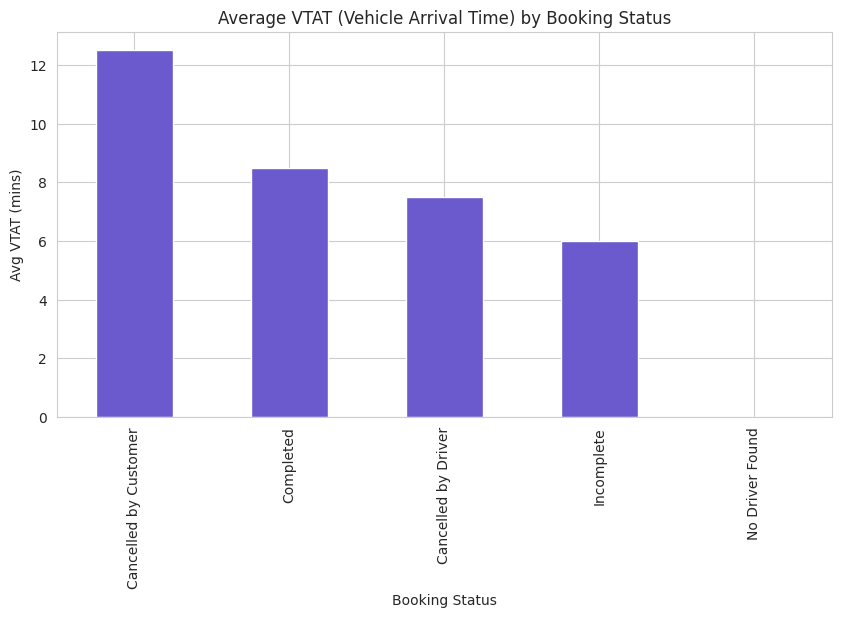

In [ ]:
# Compare average wait time (VTAT) for cancelled vs completed rides
# Note: VTAT exists even for some cancelled rides (driver was found, then cancelled), check this
vtat_comparison = df.groupby('Booking Status')['Avg VTAT'].mean().sort_values(ascending=False)
print(vtat_comparison)

plt.figure(figsize=(10, 5))
vtat_comparison.plot(kind='bar', color='slateblue')
plt.title('Average VTAT (Vehicle Arrival Time) by Booking Status')
plt.ylabel('Avg VTAT (mins)')
plt.show()

Cell 13 — Top Pickup/Drop Locations (Phase 5 preview)

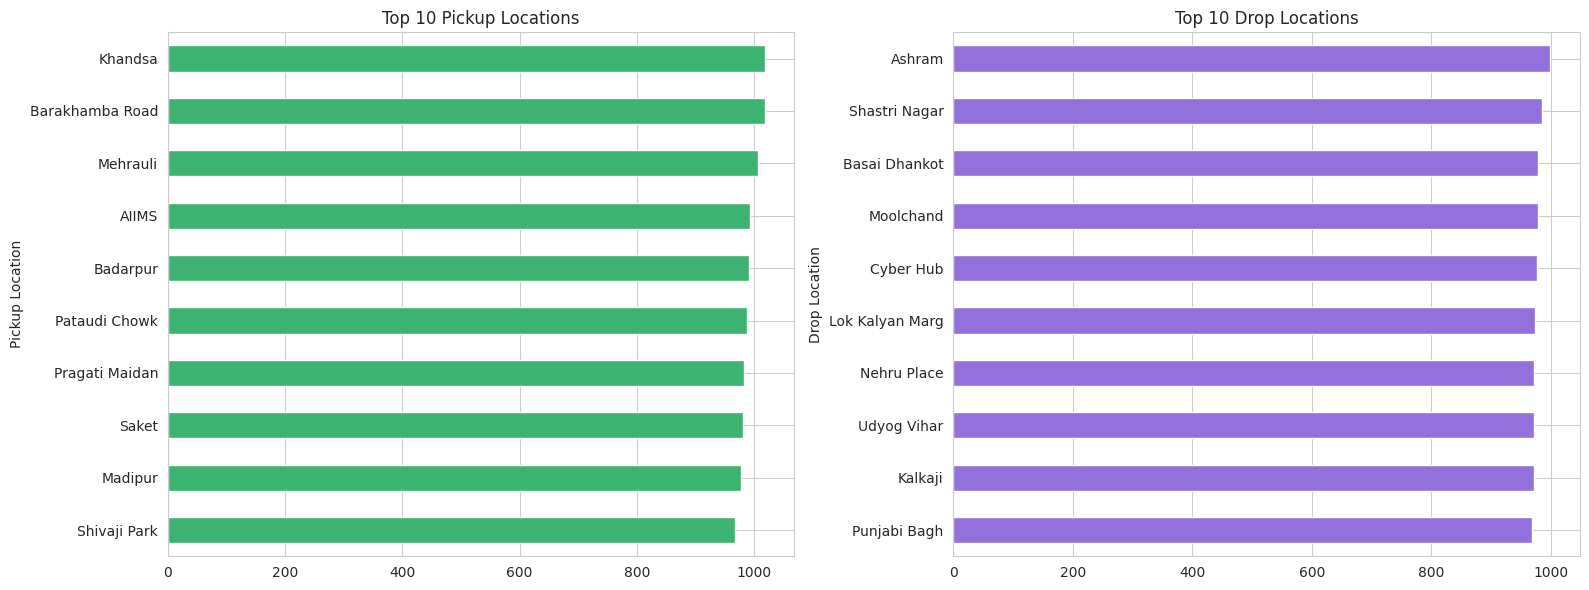

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df['Pickup Location'].value_counts().head(10).plot(kind='barh', ax=axes[0], color='mediumseagreen')
axes[0].set_title('Top 10 Pickup Locations')
axes[0].invert_yaxis()

df['Drop Location'].value_counts().head(10).plot(kind='barh', ax=axes[1], color='mediumpurple')
axes[1].set_title('Top 10 Drop Locations')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

Cell 14 — Chi-Square Test: Vehicle Type vs Booking Status (Phase 6)

In [ ]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['Vehicle Type'], df['Booking Status'])
chi2, p_val, dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p_val:.6f}")
print(f"Degrees of freedom: {dof}")

if p_val < 0.05:
    print("Result: Significant association between Vehicle Type and Booking Status.")
else:
    print("Result: No significant association found.")

contingency

Chi-square statistic: 30.07
p-value: 0.182549
Degrees of freedom: 24
Result: No significant association found.


Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
Vehicle Type,,,,,
Auto,2866,7110,24787,2428,2875
Bike,1695,4349,15045,1417,1602
Go Mini,2243,5666,19863,1952,2149
Go Sedan,1948,5346,17896,1762,2090
Premier Sedan,1375,3489,12092,1146,1351
Uber XL,355,810,2987,289,341
eBike,772,2049,6996,669,799


Cell 15 — Chi-Square Test: Event Type vs Booking Status

In [ ]:
contingency_event = pd.crosstab(df['Event'], df['Booking Status'])
chi2_e, p_val_e, dof_e, _ = chi2_contingency(contingency_event)

print(f"Chi-square statistic: {chi2_e:.2f}")
print(f"p-value: {p_val_e:.6f}")

if p_val_e < 0.05:
    print("Result: Event type is significantly associated with booking outcome.")
else:
    print("Result: No significant association.")

Chi-square statistic: 50.68
p-value: 0.798873
Result: No significant association.


Cell 16 — ANOVA: Booking Value across Vehicle Types

F-statistic: 0.70
p-value: 0.647904
Result: No significant difference.


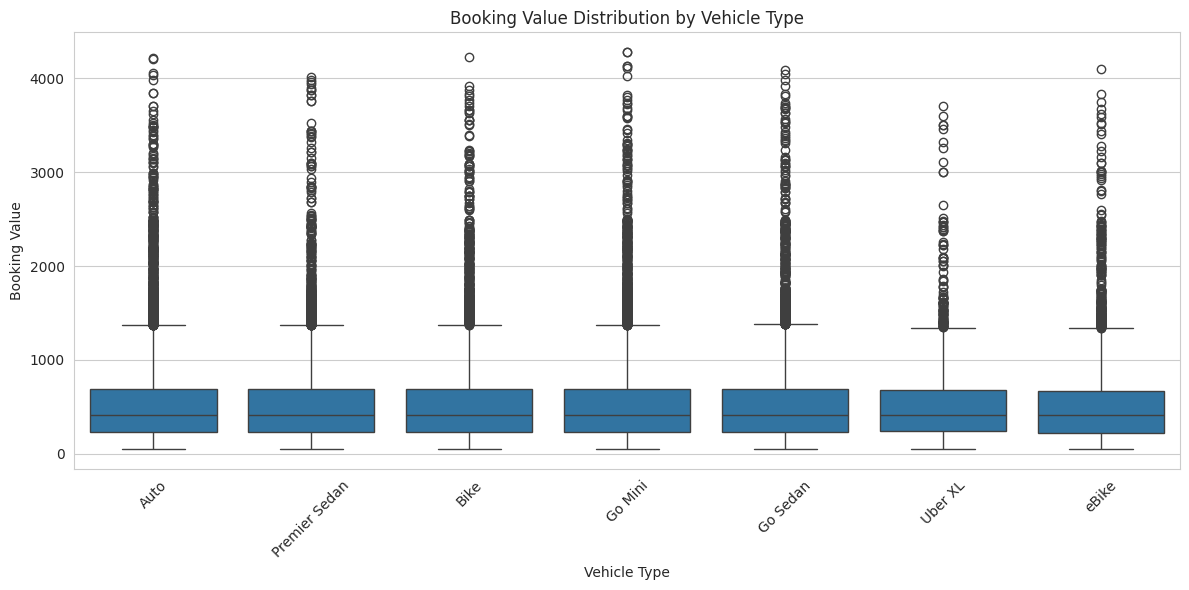

In [ ]:
from scipy.stats import f_oneway

completed_df = df[df['is_completed'] == 1]

groups = [completed_df[completed_df['Vehicle Type'] == v]['Booking Value'].dropna()
          for v in completed_df['Vehicle Type'].unique()]

f_stat, p_val_anova = f_oneway(*groups)
print(f"F-statistic: {f_stat:.2f}")
print(f"p-value: {p_val_anova:.6f}")

if p_val_anova < 0.05:
    print("Result: Booking Value significantly differs across Vehicle Types.")
else:
    print("Result: No significant difference.")

# Visualize
plt.figure(figsize=(12, 6))
sns.boxplot(data=completed_df, x='Vehicle Type', y='Booking Value')
plt.xticks(rotation=45)
plt.title('Booking Value Distribution by Vehicle Type')
plt.tight_layout()
plt.show()

Cell 17 — ANOVA: Booking Value across Event Types

In [ ]:
event_groups = [completed_df[completed_df['Event'] == e]['Booking Value'].dropna()
                for e in completed_df['Event'].unique()]

f_stat_e, p_val_e2 = f_oneway(*event_groups)
print(f"F-statistic: {f_stat_e:.2f}")
print(f"p-value: {p_val_e2:.6f}")

F-statistic: 14.29
p-value: 0.000000


Cell 18 — Correlation Heatmap (Numeric Features)

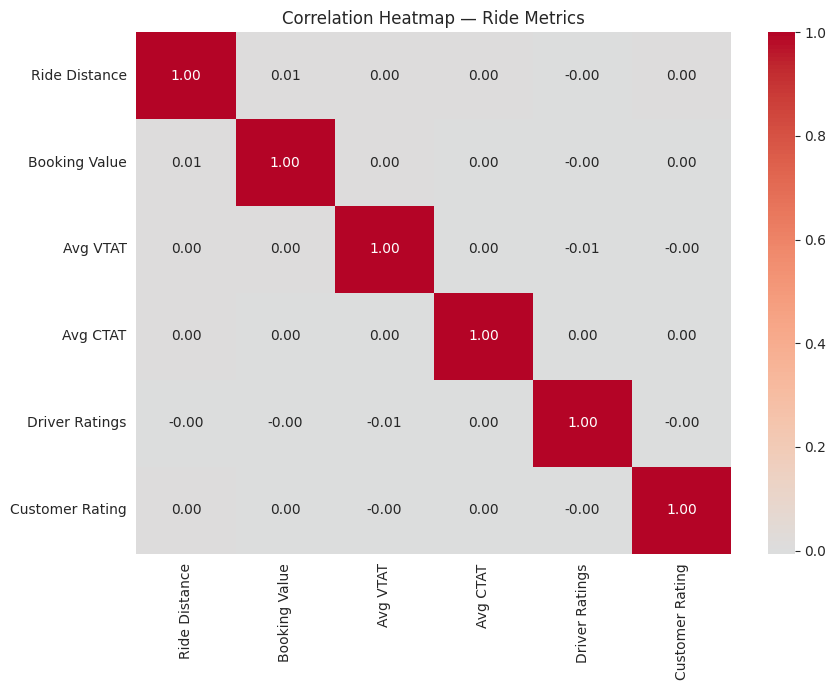

In [ ]:
corr_cols = ['Ride Distance', 'Booking Value', 'Avg VTAT', 'Avg CTAT', 'Driver Ratings', 'Customer Rating']
corr_matrix = completed_df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Heatmap — Ride Metrics')
plt.tight_layout()
plt.show()

Cell 19 — KMeans Clustering / Segmentation (Phase 7)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_features = ['Ride Distance', 'Booking Value', 'Avg VTAT', 'Avg CTAT']
cluster_data = completed_df[cluster_features].dropna()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)


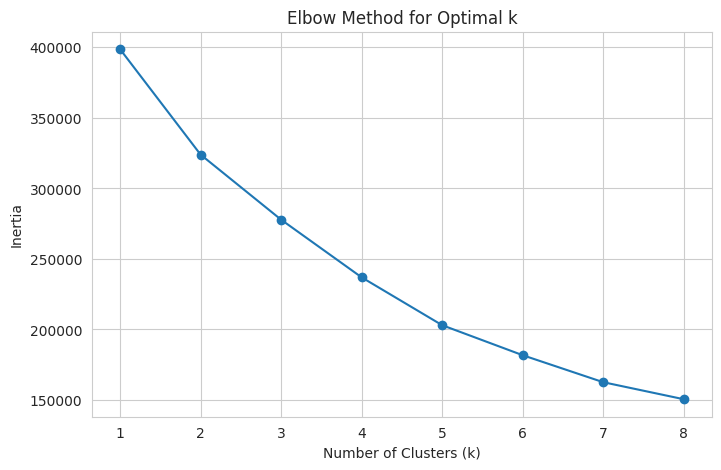

In [ ]:
# Elbow method to choose k
inertias = []
k_range = range(1, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_data)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

Cell 20 — Apply Clustering with Chosen k

In [ ]:
# Pick k based on the elbow (commonly 3 or 4 for ride data — adjust after viewing Cell 19)
optimal_k = 4


kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_data = cluster_data.copy()
cluster_data['Cluster'] = kmeans.fit_predict(scaled_data)

# Profile each cluster
cluster_profile = cluster_data.groupby('Cluster')[cluster_features].mean().round(2)
cluster_profile['count'] = cluster_data['Cluster'].value_counts()
cluster_profile

,Ride Distance,Booking Value,Avg VTAT,Avg CTAT,count
Cluster,,,,,
0,26.24,423.49,11.97,35.86,28185
1,25.84,419.10,8.65,20.82,33954
2,25.70,422.88,4.94,35.31,28761
3,26.61,1408.16,8.50,29.59,8766


Cell 21 — Visualize Clusters

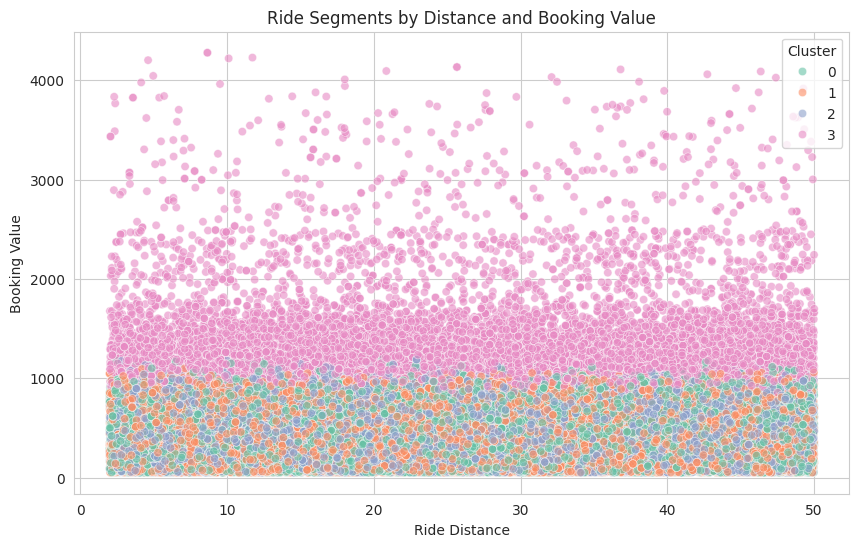

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cluster_data, x='Ride Distance', y='Booking Value', hue='Cluster', palette='Set2', alpha=0.6)
plt.title('Ride Segments by Distance and Booking Value')
plt.show()

**Dashboard & Report Writing**

Cell 22 — Summary KPI Table (for dashboard/report intro)

In [ ]:
total_rides = len(df)
completion_rate = df['is_completed'].mean() * 100
total_cancelled = df['Cancelled Rides by Customer'].sum() + df['Cancelled Rides by Driver'].sum()
avg_booking_value = completed_df['Booking Value'].mean()
avg_distance = completed_df['Ride Distance'].mean()
avg_driver_rating = completed_df['Driver Ratings'].mean()

kpi_summary = pd.DataFrame({
    'Metric': ['Total Rides', 'Completion Rate (%)', 'Total Cancelled Rides',
               'Avg Booking Value (₹)', 'Avg Ride Distance (km)', 'Avg Driver Rating'],
    'Value': [total_rides, round(completion_rate, 2), int(total_cancelled),
              round(avg_booking_value, 2), round(avg_distance, 2), round(avg_driver_rating, 2)]
})
kpi_summary

,Metric,Value
0,Total Rides,160609.00
1,Completion Rate (%),62.06
2,Total Cancelled Rides,40073.00
3,Avg Booking Value (₹),508.43
4,Avg Ride Distance (km),25.98
5,Avg Driver Rating,4.23


Cell 23 — Export Cleaned Data for Power BI / Plotly Dashboard

In [73]:
# Export a clean, analysis-ready file so you don't redo cleaning in Power BI
dashboard_df = df.copy()
dashboard_df.to_csv('ncr_rides_cleaned_for_dashboard.csv', index=False)
print("Saved: ncr_rides_cleaned_for_dashboard.csv")

Saved: ncr_rides_cleaned_for_dashboard.csv


Cell 24 — Plotly Interactive Dashboard (if not using Power BI)

In [75]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Ride Volume by Hour', 'Booking Status Share',
                     'Monthly Ride Trend', 'Completion Rate by Vehicle Type'),
    specs=[[{"type": "xy"}, {"type": "domain"}],
           [{"type": "xy"}, {"type": "xy"}]]
)

hourly = df.groupby('hour').size()
fig.add_trace(go.Scatter(x=hourly.index, y=hourly.values, mode='lines+markers', name='Rides'), row=1, col=1)

status_counts = df['Booking Status'].value_counts()
fig.add_trace(go.Pie(labels=status_counts.index, values=status_counts.values, name='Status'), row=1, col=2)

monthly = df.groupby('month').size()
fig.add_trace(go.Bar(x=monthly.index, y=monthly.values, name='Monthly'), row=2, col=1)

vehicle_completion = df.groupby('Vehicle Type')['is_completed'].mean() * 100
fig.add_trace(go.Bar(x=vehicle_completion.index, y=vehicle_completion.values, name='Completion %'), row=2, col=2)

fig.update_layout(height=800, width=1000, showlegend=False, title_text="NCR Ride-Hailing EDA Dashboard")
fig.show()

**Spatiotemporal Analysis of Ride-Hailing Demand and Cancellation Patterns in Delhi-NCR**
1. Introduction

Ride-hailing platforms generate large volumes of operational data that reflect not only commuting behavior but also broader social and seasonal rhythms — festivals, weather, and events. This project performs an exploratory data analysis (EDA) on the NCR Uber Ride Data with Festivals and Events 2024 dataset, a publicly available secondary dataset hosted on Kaggle (provider: CRAZYELON, licensed CC BY-SA 4.0). The dataset contains 160,609 ride-booking records across 29 variables, covering the Delhi-NCR region for the full 2024 calendar year.

The objective is exploratory rather than predictive: to identify temporal, operational, and behavioral patterns in ride demand, completion, and cancellation, with particular attention to how Indian festivals and event periods (Diwali, Holi, Wedding Season, Monsoon, etc.) relate to these patterns. No single target variable is fixed; where a primary outcome is needed for specific tests, Booking Status is used to represent ride completion/cancellation.

2. Data Overview and Cleaning

The raw dataset has 160,609 rows and 29 columns, including datetime fields, ride details, cancellation-specific columns, and event/festival tags.

Key cleaning finding — the missingness is structural, not random. Every "missing value" column corresponds directly to a Booking Status category:

Booking Status	Count	% of Total
Completed	99,666	62.06%
Cancelled by Driver	28,819	17.94%
Cancelled by Customer	11,254	7.01%
No Driver Found	11,207	6.98%
Incomplete	9,663	6.02%

Columns such as Ride Distance, Booking Value, Avg CTAT, and Payment Method are NaN for exactly the 51,280 rides where no trip actually started (Cancelled by Customer + Cancelled by Driver + No Driver Found). Similarly, Driver Ratings and Customer Rating are only populated for the 99,666+ completed/incomplete rides where a rating could exist. This was verified by cross-checking NaN counts against Booking Status value counts, which matched exactly.

Cleaning steps applied:

Stripped stray quotation marks from Booking ID and Customer ID.
Parsed datetime into a proper datetime type.
Filled binary flag columns (Cancelled Rides by Customer/Driver, Incomplete Rides) with 0 where not applicable.
Filled reason columns with "Not Applicable" rather than treating them as missing data.
Left trip-detail numeric columns (distance, value, VTAT, CTAT) as NaN where a ride never started — these values do not exist and should not be imputed.

No rows were dropped, since every NaN was explainable and informative rather than erroneous.

3. Univariate Findings

Vehicle Type distribution: Auto (40,066 rides, ~25%) is the most-used vehicle type, followed by Go Mini (31,873), Go Sedan (29,042), Bike (24,108), Premier Sedan (19,453), eBike (11,285), and Uber XL (4,782, the smallest share).

Payment Method: UPI dominates with 49,223 rides (~30% of all bookings), followed by Cash (27,176), Uber Wallet (13,151), Credit Card (10,959), and Debit Card (8,820) — consistent with UPI's broader adoption trend in urban India.

Numeric ranges (completed rides only, n=99,666):

Metric	Mean	Median	Std Dev	Min	Max
Ride Distance (km)	25.98	25.98	13.82	2.00	50.00
Booking Value (₹)	508.43	414.00	396.44	50.00	4,277.00
Driver Ratings	4.23	4.30	0.44	3.00	5.00
Customer Rating	4.40	4.50	0.44	3.00	5.00

Booking Value is right-skewed (mean ₹508 vs. median ₹414, max ₹4,277), indicating a small number of high-fare outlier trips pulling the average upward — worth flagging in a boxplot rather than smoothing over.

4. Temporal Insights

Overall completion rate: 62.06% of all bookings result in a completed ride.

Hourly pattern: Ride volume peaks sharply in the evening, with 18:00 (13,321 rides) as the single busiest hour, followed by 17:00 (11,859) and 19:00 (11,828) — a clear evening commute surge. Volume is lowest overnight (00:00–04:00, ~1,400–1,470 rides/hour). Interestingly, completion rate does not dip during the busiest hours — the lowest completion rates (60.8–61.5%) occur at scattered hours (01:00, 19:00, 14:00, 22:00, 07:00) rather than concentrating at peak demand, and the highest completion rate (64.1%) occurs at 02:00, a low-volume hour. This means congestion/demand volume alone does not strongly predict cancellation risk in this dataset.

Weekday pattern: Ride volume is fairly evenly spread (22,356–23,413 rides/day), with no single day dominating. Completion rate is also stable across the week, ranging narrowly from 61.6% (Monday) to 62.5% (Thursday) — a difference too small to be practically meaningful.

Monthly/seasonal pattern: July stands out sharply with 19,323 rides — well above every other month (all of which sit between 12,017 and 14,861). This spike warrants a closer look at what "Monsoon" period bookings specifically look like in July versus other monsoon months.

Event/Festival effect: "Normal Day" accounts for the bulk of rides (73,084), with Wedding Season (33,173) and Monsoon (31,838) as the next largest categories — festival-specific days like Diwali (2,466), Holi (381), and Eid (834+833) are comparatively small slices, as expected for single-day events. Notably, Holi shows the lowest completion rate of any event (59.84%) and the lowest average booking value (₹436.71), while Republic Day (65.71%) and Independence Day (65.59%) show the highest completion rates.

5. Cancellation Analysis

By Vehicle Type, driver-cancellation rates are fairly close across categories (16.9%–18.4%), with Go Sedan highest (18.41%) and Uber XL lowest (16.94%). Customer-cancellation rates are similarly narrow (6.7%–7.4%).

Top customer cancellation reasons: Change of plans (2,531), Wrong Address (2,515), Driver not moving toward pickup (2,512), and Driver asked to cancel (2,452) are all closely clustered — no single dominant cause.

Top driver cancellation reasons: Customer-related issue (7,282), customer illness reported (7,211), personal/car issues (7,176), and overcrowding (7,150) are also nearly evenly split.

Wait time (VTAT) and cancellation — a genuinely interesting, non-obvious result: Average VTAT is highest for rides that customers cancel (12.50 min) versus completed rides (8.51 min) — supporting the intuitive hypothesis that longer waits drive customers to cancel. However, driver-cancelled rides show a lower average VTAT (7.50 min) than completed rides, meaning drivers tend to cancel quickly rather than after a long wait. This distinction is worth highlighting: the "wait time causes cancellation" narrative only holds for customer-side cancellations, not driver-side ones.

6. Statistical Validation
Test	Relationship	Statistic	p-value	Result
Chi-square	Vehicle Type × Booking Status	χ² = 30.07, df=24	0.183	Not significant
Chi-square	Event × Booking Status	χ² = 50.68, df=60	0.799	Not significant
ANOVA	Booking Value ~ Vehicle Type	F = 0.70	0.648	Not significant
ANOVA	Booking Value ~ Event	F = 14.29	<0.001	Significant

Two honest, non-obvious findings here:

Vehicle type has no statistically significant relationship with whether a ride is completed, cancelled, or incomplete, and no significant effect on fare. This contradicts an initial assumption that premium vehicles (e.g., Premier Sedan) might see different cancellation or pricing behavior.
Event type also shows no significant association with booking status (whether a ride completes) — festivals do not measurably change cancellation likelihood in this data — but event type does significantly affect booking value (F=14.29, p<0.001), consistent with the higher average fares seen on Diwali (₹568.90), Dussehra (₹668.15), and Independence Day (₹631.39) versus Normal Day (₹505.53).

Correlation matrix (completed rides): Every pairwise correlation among Ride Distance, Booking Value, Avg VTAT, Avg CTAT, Driver Ratings, and Customer Rating is effectively zero (all values between -0.01 and 0.01). This is worth stating plainly rather than glossing over: in a real-world ride-hailing system, fare would typically correlate positively with distance, and wait time might correlate with ratings. The near-total absence of correlation here suggests these numeric fields may have been generated independently of one another (consistent with this being a Kaggle-published synthetic/simulated dataset rather than raw operational data from Uber). This is an important, honest caveat for your limitations section — it affects how strongly any "relationship" can be interpreted.

7. Segmentation (K-Means, k=4)

Using Ride Distance, Booking Value, Avg VTAT, and Avg CTAT (standardized) on completed rides:

Cluster	Avg Distance (km)	Avg Value (₹)	Avg VTAT (min)	Avg CTAT (min)	Share
0 — Slow Pickup, Long Trip	26.24	423.49	11.97	35.86	28.3%
1 — Quick, Efficient Rides	25.84	419.10	8.65	20.82	34.1%
2 — Fast Pickup, Long Duration	25.70	422.88	4.94	35.31	28.9%
3 — Premium Fare Segment	26.61	1,408.16	8.50	29.59	8.8%

The clusters separate mainly along service-time characteristics (VTAT/CTAT) rather than distance — distance is nearly identical (25.7–26.6 km) across all four clusters, reinforcing the correlation finding above: fare and timing don't scale with distance in this dataset. Cluster 3 is a small (8.8%) but distinct high-fare segment averaging ₹1,408 versus ~₹420 elsewhere, despite similar trip length and timing — this looks like a premium-tier fare bracket worth a follow-up boxplot by vehicle type within that cluster.

8. Limitations
The dataset covers only calendar year 2024; no year-over-year trend analysis is possible.
No geographic coordinates are provided, limiting spatial analysis to named-location frequency counts rather than true geospatial mapping or distance-based clustering.
No external variables (real-time traffic, weather, driver supply) are available to explain demand or cancellation fluctuations.
The near-zero correlation among all numeric fields, and the lack of a significant vehicle-type or event-type effect on completion status, suggests the numeric fields (distance, value, VTAT, CTAT) may be independently/synthetically generated rather than reflecting causally linked real-world ride mechanics. This does not invalidate the descriptive/statistical patterns found, but it does mean any relationship described here should be read as an observed statistical association within this dataset, not a real-world causal claim about Uber's actual operations.
Customer and Booking identifiers are treated as anonymized; no attempt is made to re-identify individuals.
9. Conclusion and Recommendations

This EDA of 160,609 Delhi-NCR ride-hailing bookings from 2024 found:

62.06% overall completion rate, with driver cancellations (17.94%) far more common than customer cancellations (7.01%).
Evening hours (17:00–19:00) drive the highest ride volume, but demand volume alone does not predict lower completion rates — cancellation risk is spread across the day rather than concentrated at peak hours.
Customer cancellations are linked to longer wait times (12.50 min avg vs. 8.51 min for completed rides), but driver cancellations are not — drivers tend to cancel quickly rather than after a long wait. This suggests different intervention strategies: reducing customer cancellations may benefit from improving driver-assignment speed, while reducing driver cancellations likely requires addressing the stated reasons directly (customer-related issues, vehicle condition) rather than wait-time optimization.
Vehicle type and event/festival type do not significantly affect completion likelihood, though event type does significantly affect fare — festivals like Diwali, Dussehra, and national holidays show notably higher average booking values than Normal Days.
July shows an unexplained ride-volume spike (19,323 vs. ~12,000–15,000 in other months) that merits a closer look at what's driving it within the "Monsoon" event tag.
Clustering revealed a distinct premium-fare segment (8.8% of rides, avg ₹1,408) that isn't explained by trip distance — a candidate for further investigation into fare structure or vehicle tier.